# Phase 1 — Industrial Quality Inspection EDA
This notebook profiles the real JPEG dataset only. No model training is performed.

In [1]:
from pathlib import Path
import hashlib
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

## Locate image folders
The notebook discovers class folders instead of assuming counts.

In [2]:
root = Path.cwd()
images = sorted(root.rglob('*.jpeg'))
class_dirs = {'def_front': 'Defective', 'ok_front': 'OK'}
rows = [{'path': p, 'source': p.parts[-4] if len(p.parts) >= 4 else '', 'label': class_dirs.get(p.parent.name, p.parent.name)} for p in images]
df = pd.DataFrame(rows)
print(f'Root: {root}')
print(f'JPEG files discovered: {len(df):,}')

Root: C:\Users\AbdElhalk\OneDrive\Desktop\computer vision\Industrial Quality Inspection
JPEG files discovered: 8,648


## Image counts by source and class
Counts are calculated from the files currently present.

In [3]:
df['dataset'] = df['path'].map(lambda p: 'casting_data' if 'casting_data' in p.parts else 'casting_512x512')
df['split'] = df['path'].map(lambda p: 'train' if 'train' in p.parts else ('test' if 'test' in p.parts else 'unsplit'))
counts = df.groupby(['dataset', 'split', 'label']).size().unstack(fill_value=0)
display(counts)
display(df.groupby(['dataset', 'split']).size().rename('images').to_frame())

label                    Defective    OK
dataset         split                   
casting_512x512 unsplit        781   519
casting_data    test           453   262
                train         3758  2875

images
dataset         split          
casting_512x512 unsplit    1300
casting_data    test        715
                train      6633

## Class distribution
The chart shows the measured class totals across the full folder.

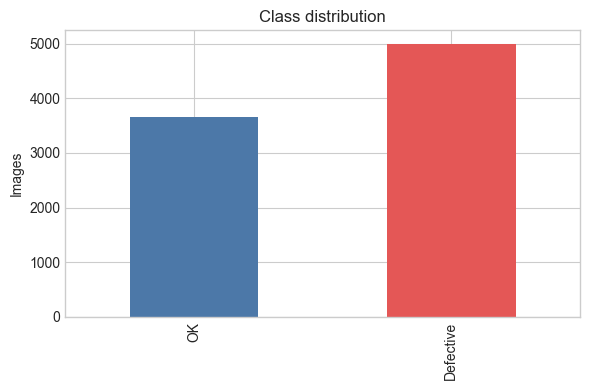

In [4]:
class_counts = df['label'].value_counts().reindex(['OK', 'Defective'])
ax = class_counts.plot.bar(color=['#4C78A8', '#E45756'], figsize=(6, 4))
ax.set(title='Class distribution', xlabel='', ylabel='Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=160)
plt.show()

## Validate files and image dimensions
Each image is opened and verified; failures are recorded rather than hidden.

In [5]:
corrupt, sizes = [], []
for path in df['path']:
    try:
        with Image.open(path) as im: im.verify(); sizes.append((path, im.size, im.mode))
    except Exception as exc: corrupt.append((path, type(exc).__name__, str(exc)))
print(f'Valid: {len(sizes):,} | Corrupted/unreadable: {len(corrupt):,}')

Valid: 8,648 | Corrupted/unreadable: 0


,size,mode,images
0,"(300, 300)",RGB,7348
1,"(512, 512)",RGB,1300


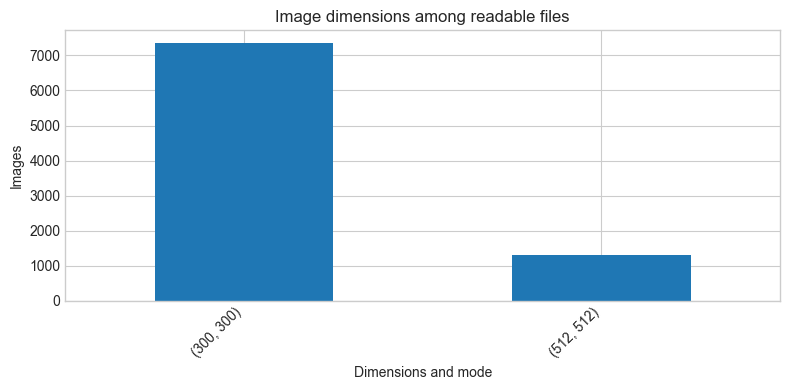

In [6]:
size_df = pd.DataFrame(sizes, columns=['path', 'size', 'mode'])
size_counts = size_df.value_counts(['size', 'mode']).rename('images').reset_index()
display(size_counts.head(20))
ax = size_counts.head(10).set_index('size')['images'].plot.bar(figsize=(8, 4))
ax.set(title='Image dimensions among readable files', xlabel='Dimensions and mode', ylabel='Images')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.savefig('image_dimensions.png', dpi=160); plt.show()

## Detect exact duplicate files
SHA-256 hashes identify byte-for-byte duplicates without modifying the data.

In [7]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''): h.update(chunk)
    return h.hexdigest()
df['sha256'] = df['path'].map(sha256)
dupes = df[df.duplicated('sha256', keep=False)].sort_values('sha256')
print(f'Files in exact-duplicate groups: {len(dupes):,}')
display(dupes[['dataset', 'split', 'label', 'path', 'sha256']].head(20))

Files in exact-duplicate groups: 128


,dataset,split,label,path,sha256
5831,casting_data,train,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,0387c085d3bd0ae07ecb8dd52ac00d65663ebce8a641e7...
1792,casting_data,test,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,0387c085d3bd0ae07ecb8dd52ac00d65663ebce8a641e7...
1778,casting_data,test,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,05184fa783840ba2589023ce5527a594c21128674525df...
5815,casting_data,train,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,05184fa783840ba2589023ce5527a594c21128674525df...
1800,casting_data,test,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,06113b5dd4b161d7160f3b6477a02a0fe94d9b567ade35...
5846,casting_data,train,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,06113b5dd4b161d7160f3b6477a02a0fe94d9b567ade35...
1984,casting_data,test,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,08ca14d5672e6b79bf0d6ef2dc2d25926ef18f67a658d0...
8335,casting_data,train,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,08ca14d5672e6b79bf0d6ef2dc2d25926ef18f67a658d0...
5775,casting_data,train,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,0b09411e68be8f06e90a7ef0480024833969389074e479...
1755,casting_data,test,OK,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,0b09411e68be8f06e90a7ef0480024833969389074e479...


## Representative OK and defective examples
Examples are sampled deterministically from the real files.

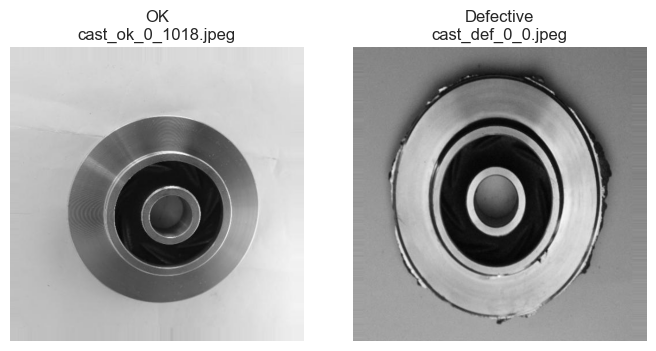

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
for ax, label in zip(axes, ['OK', 'Defective']):
    path = df.loc[df['label'].eq(label), 'path'].sort_values().iloc[0]
    with Image.open(path) as im: ax.imshow(im, cmap='gray'); ax.set_title(f'{label}\n{path.name}')
    ax.axis('off')
plt.tight_layout(); plt.savefig('representative_examples.png', dpi=160); plt.show()

## Phase 1 conclusion
Use the measured tables and saved figures to document the dataset before any modeling begins.

In [9]:
summary = {'total_files': len(df), 'valid_files': len(sizes), 'corrupt_files': len(corrupt), 'exact_duplicate_files': len(dupes), 'unique_dimensions': size_df['size'].nunique()}
print(summary)
print('Phase 1 EDA complete; no model training was run.')

{'total_files': 8648, 'valid_files': 8648, 'corrupt_files': 0, 'exact_duplicate_files': 128, 'unique_dimensions': 2}
Phase 1 EDA complete; no model training was run.
